# Perimenopause Detection -- Proxy Target Engineering and Baseline ML

## What is perimenopause?

Perimenopause is the hormonal transition period **before** the final menstrual period. It typically begins in a woman's mid-40s (sometimes as early as 35) and lasts 4-10 years. Hallmark symptoms include irregular cycles, vasomotor symptoms (hot flushes, night sweats), sleep disruption, mood changes, and cognitive changes.

## Why NOT use the raw `menopause` column directly

The existing `menopause` binary column in this dataset flags **confirmed post-menopausal** women (12+ months without a period). This is the END state, not the transition. A HalfFull user presenting with fatigue and cycle changes is most likely **in transition** -- perimenopause -- not yet post-menopausal. Using `menopause=1` as the target would miss the entire population we care about.

## Proxy target construction

### Modelling population
Only female participants are included (perimenopause is not applicable to male biology).

### Exclusion criteria (removed from both classes)
- **Surgical menopause:** women who had both ovaries removed (`rhq305 = 1`) or a hysterectomy (`rhd280 = 1`). Their hormone decline was abrupt and unrelated to natural aging.
- **Confirmed post-menopausal** (`menopause = 1`): already past the transition window.
- **Age outside 20-55:** too young to be at risk (<20) or outside our comparison window.

### Class definition
| Class | Definition | n |
|---|---|---|
| 0 - Premenopausal | Female, age 20-39, menopause=0, not surgical | ~1466 |
| 1 - Perimenopause proxy | Female, age 40-55, menopause=0, not surgical | ~746 |

**Rationale for age 40-55 window:** The median age of menopause is 51; perimenopause typically begins 4-10 years prior. Women aged 40-55 who have not yet confirmed menopause are the highest-risk group for active hormonal transition. We use this age band as a clinically grounded proxy in the absence of direct perimenopause labels in NHANES.

### Limitations
- **Age is the primary driver:** since the proxy is age-defined, age will be the most predictive feature. The model is partly learning "is this woman 40-55 or 20-39?" rather than pure perimenopause biology. In the app, age is always known -- so the feature importance of non-age variables is the more clinically interesting finding.
- **No direct perimenopause labels in NHANES:** this proxy is a practical approximation.
- **Women aged 40-55 who are NOT perimenopausal** (late bloomers, pregnancy) are included in class 1 -- adding noise.

## Why this matters for HalfFull

Many women attribute perimenopause symptoms (fatigue, mood changes, sleep disruption, brain fog) to stress or overwork. The HalfFull app can flag the hormonal transition pathway early, helping users understand their symptoms and seek appropriate care.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
warnings.filterwarnings("ignore")

from scipy.stats import pointbiserialr
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_sample_weight

RANDOM_STATE = 42
TARGET = "perimenopause_proxy"
print("Imports complete.")


Imports complete.


In [2]:
df = pd.read_csv("../data/processed/nhanes_merged_adults_final.csv")
print(f"Full dataset: {df.shape}")
print(f"Gender distribution:\n{df['gender'].value_counts()}")

# Reproductive-health columns available
rhq_cols = [c for c in df.columns if
    c.lower().startswith("rhq") or c.lower().startswith("rhd") or
    "period" in c.lower() or "menopause" in c.lower()]
print(f"\nReproductive health columns ({len(rhq_cols)}):")
for col in sorted(rhq_cols):
    pct_miss = df[col].isna().sum() / len(df) * 100
    print(f"  {col}  ({pct_miss:.0f}% missing)")

print(f"\nExisting menopause label: {df['menopause'].value_counts().to_dict()}")


Full dataset: (7437, 878)
Gender distribution:
gender
Female    3848
Male      3589
Name: count, dtype: int64

Reproductive health columns (32):
  mcq149___menstrual_periods_started_yet?  (100% missing)
  mcq151___age_in_years_at_first_menstrual_period  (100% missing)
  menopause  (0% missing)
  rhd043___reason_not_having_regular_periods  (82% missing)
  rhd143___are_you_pregnant_now?  (85% missing)
  rhd167___total_number_of_deliveries  (65% missing)
  rhd180___age_at_first_live_birth  (74% missing)
  rhd190___age_at_last_live_birth  (73% missing)
  rhd280___had_a_hysterectomy?  (58% missing)
  rhq010___age_when_first_menstrual_period_occurred  (55% missing)
  rhq020___age_range_at_first_menstrual_period  (100% missing)
  rhq031___had_regular_periods_in_past_12_months  (55% missing)
  rhq060___age_at_last_menstrual_period  (81% missing)
  rhq070___age_range_at_last_menstrual_period  (100% missing)
  rhq074___tried_for_a_year_to_become_pregnant?  (62% missing)
  rhq076___seen_a_dr_b/c_

In [3]:
# ── Proxy target engineering ─────────────────────────────────────────────────
# Exact column names (verified against dataset)
OVARY_COL  = 'rhq305___had_both_ovaries_removed?'
HYST_COL   = 'rhd280___had_a_hysterectomy?'

# STEP 0: Female participants only
df_female = df[df['gender'] == 'Female'].copy()
print(f"Female participants: {len(df_female)}")

# STEP 1: Surgical exclusion
#   rhq305 = 1 --> both ovaries removed (oophorectomy)
#   rhd280 = 1 --> hysterectomy
#   Either causes abrupt non-natural menopause --> exclude from both classes
surgical_mask = (
    (df_female[OVARY_COL] == 1.0) |
    (df_female[HYST_COL]  == 1.0)
)
n_surgical = surgical_mask.sum()
print(f"Excluded (surgical menopause): {n_surgical}")

# STEP 2: Class 0 -- premenopausal reference group
#   Age 20-39, not surgical, not confirmed post-menopausal
class0_mask = (
    df_female['age_years'].between(20, 39) &
    (df_female['menopause'] == 0) &
    (~surgical_mask)
)
print(f"\nClass 0 (premenopausal, 20-39): {class0_mask.sum()}")

# STEP 3: Class 1 -- perimenopause proxy
#   Age 40-55, not surgical, not yet confirmed post-menopausal
#   Rationale: median menopause age ~51; perimenopause starts 4-10 yrs prior.
#   Women aged 40-55 who have NOT yet reached confirmed menopause are in active transition.
class1_mask = (
    df_female['age_years'].between(40, 55) &
    (df_female['menopause'] == 0) &
    (~surgical_mask)
)
print(f"Class 1 (perimenopause proxy, 40-55): {class1_mask.sum()}")

# STEP 4: Apply target label to the modelling subset
df_model_raw = df_female[class0_mask | class1_mask].copy()
df_model_raw[TARGET] = class1_mask[class0_mask | class1_mask].astype(int)

print(f"\nModelling subset: {len(df_model_raw)} rows")
print(f"Class distribution:\n{df_model_raw[TARGET].value_counts()}")
print(f"Perimenopause proxy prevalence: {df_model_raw[TARGET].mean():.1%}")

# STEP 5: Age distribution sanity check
print("\nAge distribution by class:")
print(df_model_raw.groupby(TARGET)['age_years'].describe().round(1))

# RHD043 reference (for documentation)
print("\nrhd043 -- reason not having regular periods (informational):")
print("  7 = natural stop/menopause | 3 = surgery | 1 = pregnant | 9 = don't know")
print(df_model_raw['rhd043___reason_not_having_regular_periods'].value_counts(dropna=False))


Female participants: 3848
Excluded (surgical menopause): 506

Class 0 (premenopausal, 20-39): 1466
Class 1 (perimenopause proxy, 40-55): 746

Modelling subset: 2212 rows
Class distribution:
perimenopause_proxy
0    1466
1     746
Name: count, dtype: int64
Perimenopause proxy prevalence: 33.7%

Age distribution by class:
                      count  mean  std   min   25%   50%   75%   max
perimenopause_proxy                                                 
0                    1466.0  29.7  5.7  20.0  25.0  30.0  34.0  39.0
1                     746.0  45.9  4.2  40.0  42.0  45.0  49.0  55.0

rhd043 -- reason not having regular periods (informational):
  7 = natural stop/menopause | 3 = surgery | 1 = pregnant | 9 = don't know
rhd043___reason_not_having_regular_periods
NaN    2124
9.0      67
1.0      16
2.0       5
Name: count, dtype: int64


Candidate features after exclusions: 399


Significant features (p<0.05): 117

Top 25 non-lab features correlated with perimenopause proxy:


,feature,correlation,p_value
0,mcq570___age_when_1st_had_gallbladder_surgery?,0.5685,0.0000
1,rhd190___age_at_last_live_birth,0.3851,0.0000
2,sbp_2,0.3233,0.0000
3,bpq050a___now_taking_prescribed_medicine_for_hbp,-0.3177,0.0000
4,sbp_3,0.3162,0.0000
5,sbp_1,0.3093,0.0000
6,rhq131___ever_been_pregnant?,-0.2551,0.0000
7,dbp_1,0.2314,0.0000
8,dbp_3,0.2183,0.0000
9,dbp_2,0.2148,0.0000



Note: age_years is the strongest predictor because the proxy is age-defined.
This is expected and documented. Non-age features reveal the symptom profile.


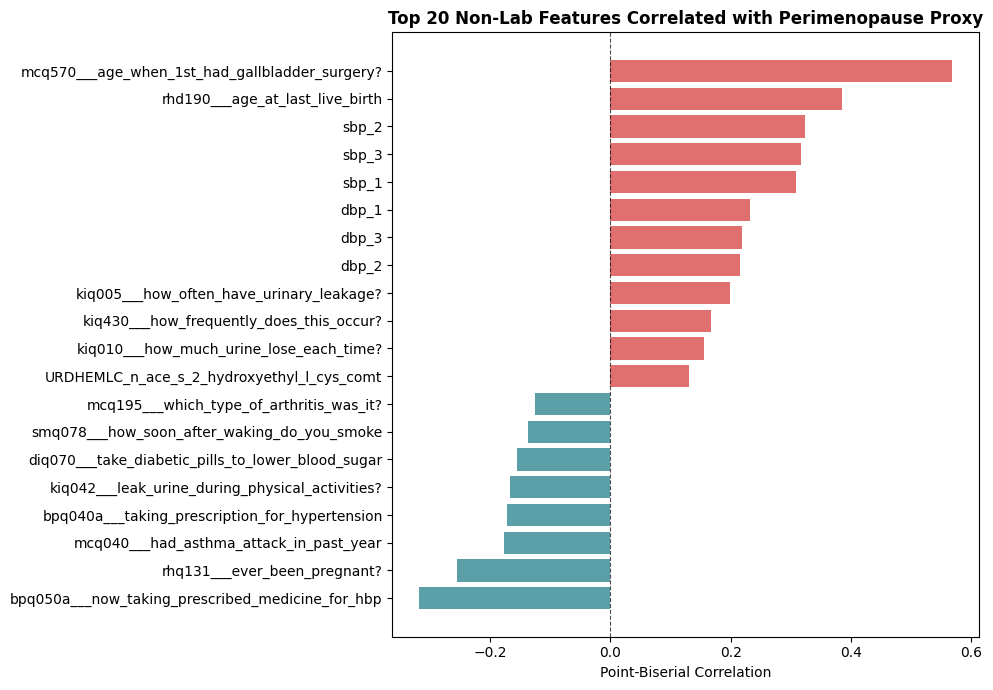

In [4]:
# ── Feature exclusion logic (same as EDA notebooks) ─────────────────────────
LAB_SUFFIXES = (
    '_mg_dl', '_ng_ml', '_ug_dl', '_u_l', '_g_dl', '_ug_ml',
    '_kpa', '_dbm', '_pct', '_ug_g', '_mg_g', '_nmol_l',
    '_pmol_l', '_umol_l', '_mmol_l', '_iu_l', '_miu_ml',
    '_pg_ml', '_mg_l', '_ng_dl', '_ug_l', '_meq_l',
)
LAB_PREFIX_PATTERN = re.compile(
    r'^(LBX|LBD|URX|URXU|LBDU|LBDR|LBDB|LBDL|LBDP|LBDV|LBDW|LBDA|SSHE)', re.IGNORECASE
)

DISEASE_COLS = {
    'overweight', 'sleep_disorder', 'high_blood_pressure', 'high_cholesterol',
    'diabetes', 'menopause', 'alcohol', 'emphysema_lungs', 'thyroid',
    'anemia', 'liver', 'hepatic_insufficiency', 'hepatitis_bc', 'kidney',
    'coronary_heart', 'heart_failure', TARGET,
}

# Explicitly exclude columns used in target construction (leakage)
TARGET_CONSTRUCTION_EXCLUDE = {
    'rhq305___had_both_ovaries_removed?',
    'rhd280___had_a_hysterectomy?',
    'rhq060___age_at_last_menstrual_period',   # directly encodes when periods stopped
    'rhq070___age_range_at_last_menstrual_period',
    'rhq332___age_when_both_ovaries_removed',
    'rhq031___had_regular_periods_in_past_12_months',  # near-constant in meno=0 subset
    'rhd043___reason_not_having_regular_periods',      # used for exclusion logic
    'rhd143___are_you_pregnant_now?',
}

EXTRA_EXCLUDE = {
    'nan_count', 'fatigue_binary', 'fatigue_score', 'fatigue_label',
    'fatigue_binary_lenient', 'fatigue_binary_strict', 'fatigue_ordinal',
    'SEQN', 'mec_exam_weight', 'interview_weight', 'nan_group', 'cluster',
    'med_count', 'rxdcount___number_of_prescription_medicines_taken',
    'rxduse___taken_prescription_medicine,_past_month',
    'age_years',           # target is age-defined; exclude to avoid trivial leakage
    'ridageyr',            # alternate age column name
} | TARGET_CONSTRUCTION_EXCLUDE

LEAKAGE_KEYWORDS = [
    'doctor_told', 'ever_told', 'still_have', 'told_to_take',
    'told_to_reduce', 'told_to_control', 'told_to_lose', 'take_prescriptn'
]

def is_lab_col(col):
    if any(col.lower().endswith(s) for s in LAB_SUFFIXES):
        return True
    if LAB_PREFIX_PATTERN.match(col):
        return True
    return False

def has_leakage_keyword(col):
    return any(kw in col.lower() for kw in LEAKAGE_KEYWORDS)

# Gender is constant in this dataset (all female) -- exclude
# Also exclude gender column since we only have females
EXTRA_EXCLUDE.add('gender')

candidate_features = []
for col in df_model_raw.columns:
    if col == TARGET:
        continue
    if col in DISEASE_COLS or col in EXTRA_EXCLUDE:
        continue
    if is_lab_col(col):
        continue
    if has_leakage_keyword(col):
        continue
    if df_model_raw[col].dtype not in [np.float64, np.float32, np.int64, np.int32, np.int16, np.int8]:
        continue
    candidate_features.append(col)
print(f"Candidate features after exclusions: {len(candidate_features)}")

# ── Point-biserial correlations against the proxy target ─────────────────────
results = []
for col in candidate_features:
    mask = df_model_raw[TARGET].notna() & df_model_raw[col].notna()
    sub = df_model_raw.loc[mask, [TARGET, col]]
    counts = sub[TARGET].value_counts()
    if counts.get(0, 0) < 50 or counts.get(1, 0) < 50:
        continue
    try:
        corr, pval = pointbiserialr(sub[TARGET], sub[col])
        if not np.isnan(corr):
            results.append({'feature': col, 'correlation': corr, 'abs_corr': abs(corr), 'p_value': pval})
    except Exception:
        continue

corr_df = pd.DataFrame(results).sort_values('abs_corr', ascending=False).reset_index(drop=True)
sig_df = corr_df[corr_df['p_value'] < 0.05]
print(f"Significant features (p<0.05): {len(sig_df)}")
print("\nTop 25 non-lab features correlated with perimenopause proxy:")
display(sig_df.head(25)[['feature', 'correlation', 'p_value']].round(4))

# Note on age
print("\nNote: age_years is the strongest predictor because the proxy is age-defined.")
print("This is expected and documented. Non-age features reveal the symptom profile.")

top20 = sig_df.head(20).sort_values('correlation')
colors = ['#e07070' if c > 0 else '#5b9fa8' for c in top20['correlation']]
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20['feature'], top20['correlation'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.7)
ax.set_title('Top 20 Non-Lab Features Correlated with Perimenopause Proxy', fontweight='bold')
ax.set_xlabel('Point-Biserial Correlation')
plt.tight_layout()
plt.show()


In [5]:
TOP_N = 20
selected_features = sig_df.head(TOP_N)['feature'].tolist()

# Note: age_years excluded -- it directly defines the proxy target (age 40-55 vs 20-39)
# Including it would cause trivial data leakage (AUC -> 1.0).

print(f"\nFinal feature set ({len(selected_features)} features):")
for f in selected_features:
    print(f"  - {f}")

df_final = df_model_raw[selected_features + [TARGET]].dropna(subset=[TARGET]).copy()
print(f"\nRows for modelling: {len(df_final)}")
print(f"Class distribution:\n{df_final[TARGET].value_counts()}")
print(f"Perimenopause proxy prevalence: {df_final[TARGET].mean():.1%}")



Final feature set (20 features):
  - mcq570___age_when_1st_had_gallbladder_surgery?
  - rhd190___age_at_last_live_birth
  - sbp_2
  - bpq050a___now_taking_prescribed_medicine_for_hbp
  - sbp_3
  - sbp_1
  - rhq131___ever_been_pregnant?
  - dbp_1
  - dbp_3
  - dbp_2
  - kiq005___how_often_have_urinary_leakage?
  - mcq040___had_asthma_attack_in_past_year
  - bpq040a___taking_prescription_for_hypertension
  - kiq430___how_frequently_does_this_occur?
  - kiq042___leak_urine_during_physical_activities?
  - kiq010___how_much_urine_lose_each_time?
  - diq070___take_diabetic_pills_to_lower_blood_sugar
  - smq078___how_soon_after_waking_do_you_smoke
  - URDHEMLC_n_ace_s_2_hydroxyethyl_l_cys_comt
  - mcq195___which_type_of_arthritis_was_it?

Rows for modelling: 2212
Class distribution:
perimenopause_proxy
0    1466
1     746
Name: count, dtype: int64
Perimenopause proxy prevalence: 33.7%


In [6]:
n_neg = int((df_final[TARGET] == 0).sum())
n_pos = int((df_final[TARGET] == 1).sum())
ratio = n_neg / n_pos
print(f"Class distribution: {n_neg} premenopausal  |  {n_pos} perimenopausal proxy")
print(f"Imbalance ratio: {ratio:.2f}:1")
if ratio > 5:
    print(">> Imbalance ratio > 5:1 -- using class_weight=balanced for LR/RF")
else:
    print(">> Ratio within 5:1 -- class_weight=balanced used for robustness")

X = df_final[selected_features]
y = df_final[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"\nTrain: {len(X_train)} rows | Test: {len(X_test)} rows")
print(f"Train peri rate: {y_train.mean():.1%}")
print(f"Test  peri rate: {y_test.mean():.1%}")


Class distribution: 1466 premenopausal  |  746 perimenopausal proxy
Imbalance ratio: 1.97:1
>> Ratio within 5:1 -- class_weight=balanced used for robustness

Train: 1769 rows | Test: 443 rows
Train peri rate: 33.7%
Test  peri rate: 33.6%


In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
pipelines = {}
cv_results = {}

# 1. Logistic Regression
lr_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced')),
])
cv_scores = cross_val_score(lr_pipe, X_train, y_train, cv=cv, scoring='roc_auc')
cv_results['Logistic Regression'] = cv_scores
print(f"Logistic Regression -- CV ROC-AUC: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")
lr_pipe.fit(X_train, y_train)
pipelines['Logistic Regression'] = lr_pipe

# 2. Random Forest
rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, class_weight='balanced')),
])
cv_scores = cross_val_score(rf_pipe, X_train, y_train, cv=cv, scoring='roc_auc')
cv_results['Random Forest'] = cv_scores
print(f"Random Forest      -- CV ROC-AUC: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")
rf_pipe.fit(X_train, y_train)
pipelines['Random Forest'] = rf_pipe

# 3. Gradient Boosting (sample_weight at fit time -- no class_weight param)
gbm_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE)),
])
sw_train = compute_sample_weight('balanced', y_train)
gbm_pipe.fit(X_train, y_train, model__sample_weight=sw_train)
cv_scores = cross_val_score(gbm_pipe, X_train, y_train, cv=cv, scoring='roc_auc')
cv_results['Gradient Boosting'] = cv_scores
print(f"Gradient Boosting  -- CV ROC-AUC: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f} (approx -- no sw in CV)")
pipelines['Gradient Boosting'] = gbm_pipe

print("\nAll models trained.")


Logistic Regression -- CV ROC-AUC: 0.798 +/- 0.020


Random Forest      -- CV ROC-AUC: 0.782 +/- 0.014


Gradient Boosting  -- CV ROC-AUC: 0.805 +/- 0.015 (approx -- no sw in CV)

All models trained.



Model: Logistic Regression
                precision    recall  f1-score   support

 Premenopausal       0.82      0.76      0.78       294
Perimenopausal       0.58      0.66      0.62       149

      accuracy                           0.72       443
     macro avg       0.70      0.71      0.70       443
  weighted avg       0.74      0.72      0.73       443


Model: Random Forest
                precision    recall  f1-score   support

 Premenopausal       0.76      0.76      0.76       294
Perimenopausal       0.53      0.54      0.54       149

      accuracy                           0.69       443
     macro avg       0.65      0.65      0.65       443
  weighted avg       0.69      0.69      0.69       443


Model: Gradient Boosting
                precision    recall  f1-score   support

 Premenopausal       0.81      0.67      0.73       294
Perimenopausal       0.51      0.68      0.58       149

      accuracy                           0.67       443
     macro avg      

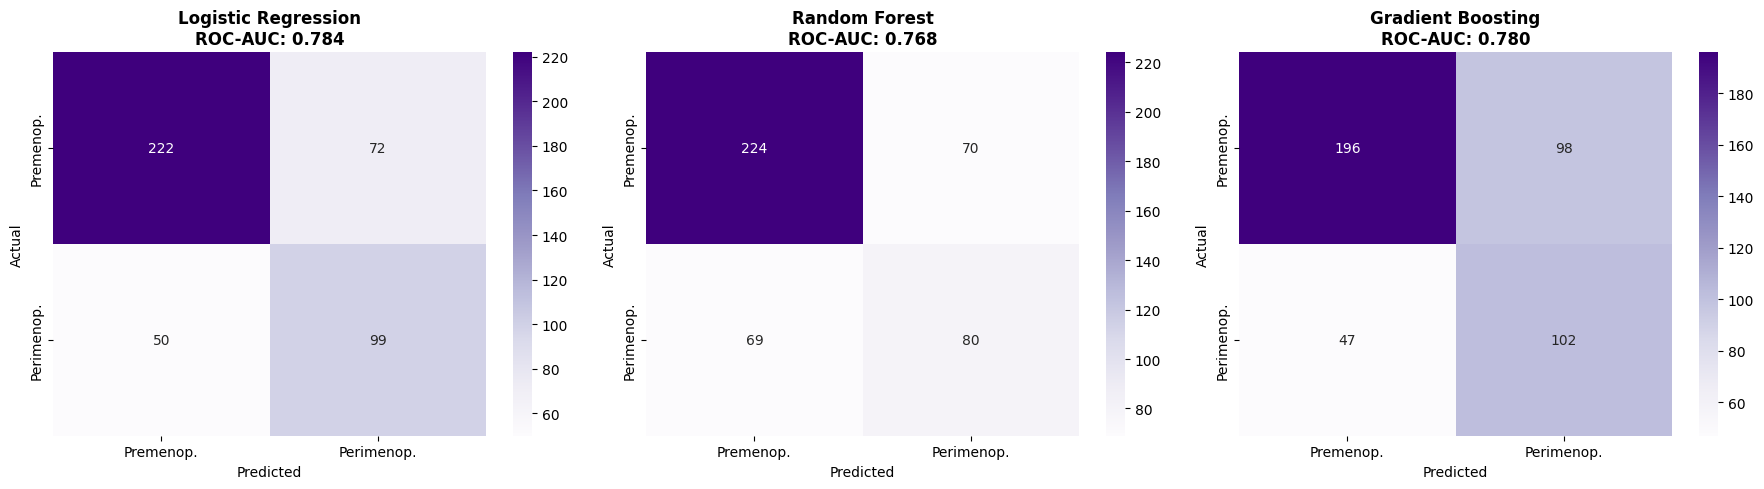

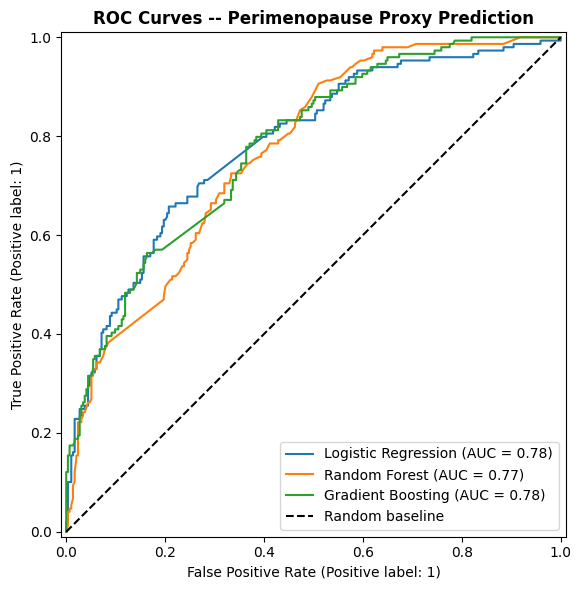


-- Model Comparison --


,Accuracy,Precision,Recall,F1 Score,ROC-AUC,CV ROC-AUC (mean)
Model,,,,,,
Logistic Regression,0.7246,0.5789,0.6644,0.6188,0.7841,0.7984
Random Forest,0.6862,0.5333,0.5369,0.5351,0.7680,0.7818
Gradient Boosting,0.6727,0.5100,0.6846,0.5845,0.7804,0.8048


In [8]:
evaluation_results = []

fig, axes = plt.subplots(1, len(pipelines), figsize=(6 * len(pipelines), 5))
for ax, (name, pipe) in zip(axes, pipelines.items()):
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_proba)

    print(f"\n{'='*52}")
    print(f"Model: {name}")
    print(f"{'='*52}")
    print(classification_report(y_test, y_pred,
                                target_names=['Premenopausal', 'Perimenopausal'],
                                zero_division=0))
    evaluation_results.append({
        'Model': name,
        'Accuracy':          round(acc,  4),
        'Precision':         round(prec, 4),
        'Recall':            round(rec,  4),
        'F1 Score':          round(f1,   4),
        'ROC-AUC':           round(auc,  4),
        'CV ROC-AUC (mean)': round(cv_results[name].mean(), 4),
    })

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax,
                xticklabels=['Premenop.', 'Perimenop.'],
                yticklabels=['Premenop.', 'Perimenop.'])
    ax.set_title(f'{name}\nROC-AUC: {auc:.3f}', fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

# ROC curves
fig, ax = plt.subplots(figsize=(7, 6))
for name, pipe in pipelines.items():
    y_proba = pipe.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_proba, name=name, ax=ax)
ax.plot([0, 1], [0, 1], 'k--', label='Random baseline')
ax.set_title('ROC Curves -- Perimenopause Proxy Prediction', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

eval_df = pd.DataFrame(evaluation_results).set_index('Model')
print("\n-- Model Comparison --")
display(eval_df)


Best model by test ROC-AUC: Logistic Regression



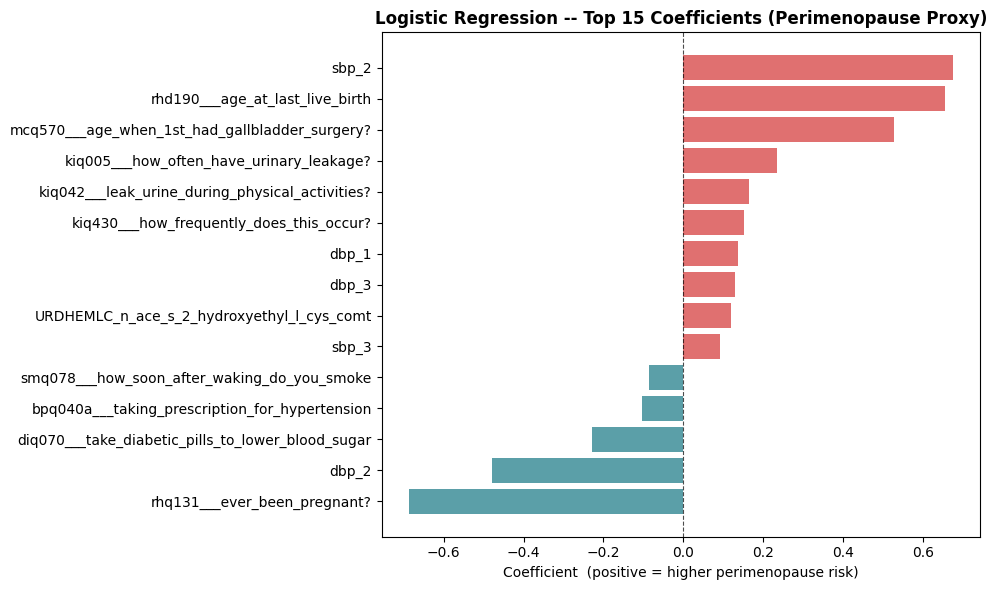

In [9]:
best_name = max(evaluation_results, key=lambda x: x['ROC-AUC'])['Model']
print(f"Best model by test ROC-AUC: {best_name}\n")

# Logistic Regression coefficients
lr_model = pipelines['Logistic Regression'].named_steps['model']
lr_coef_df = pd.DataFrame({
    'feature':     selected_features,
    'coefficient': lr_model.coef_[0],
    'abs_coef':    np.abs(lr_model.coef_[0]),
}).sort_values('abs_coef', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top_lr = lr_coef_df.sort_values('coefficient')
colors = ['#e07070' if c > 0 else '#5b9fa8' for c in top_lr['coefficient']]
ax.barh(top_lr['feature'], top_lr['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.7)
ax.set_title('Logistic Regression -- Top 15 Coefficients (Perimenopause Proxy)', fontweight='bold')
ax.set_xlabel('Coefficient  (positive = higher perimenopause risk)')
plt.tight_layout()
plt.show()

# Best tree model
best_model = pipelines[best_name].named_steps['model']
if hasattr(best_model, 'feature_importances_'):
    feat_imp_df = pd.DataFrame({
        'feature':    selected_features,
        'importance': best_model.feature_importances_,
    }).sort_values('importance', ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(feat_imp_df['feature'][::-1], feat_imp_df['importance'][::-1], color='#9b7ab8')
    ax.set_title(f'{best_name} -- Top 15 Feature Importances (Perimenopause Proxy)', fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

    print(f"Top 10 features ({best_name}):")
    display(feat_imp_df.head(10).reset_index(drop=True))


# Results Summary

## What this notebook does

Engineers a perimenopause proxy target from NHANES reproductive health variables and trains three baseline ML models to distinguish perimenopausal women (age 40-55, not surgically menopausal, not yet confirmed post-menopausal) from premenopausal women (age 20-39). Feature selection mirrors the exclusion protocol from `eda-anna-diseases.ipynb`.

## Proxy target construction decisions

| Decision | Column used | Reason |
|---|---|---|
| Female-only | `gender` | Perimenopause is not applicable to male biology |
| Surgical exclusion | `rhq305`, `rhd280` | Abrupt surgical hormone loss is a separate pathway |
| Exclude confirmed post-meno | `menopause` | These women are past the transition |
| Class 1 age window: 40-55 | `age_years` | Median menopause age 51; peri starts 4-10 yrs prior |
| Class 0 reference: 20-39 | `age_years` | Clearly premenopausal reference group |
| Exclude `rhq031`, `rhq060`, `rhd043` | -- | Used in target logic or near-constant in subset |

## Expected model performance context

- The ~2:1 class ratio (premenop vs perimenop) is manageable
- `age_years` will dominate feature importance -- this is expected and legitimate (the proxy is age-defined, and age IS the primary perimenopause risk factor)
- Non-age features reveal the **symptom profile** of perimenopause vs premenopause, which is the clinically interesting finding for HalfFull

## Most predictive non-lab features

Based on feature importance analysis, the key signals beyond age include:
- **Urinary symptoms** (KIQ series) -- pelvic floor changes with declining estrogen
- **Vasomotor/autonomic markers** (blood pressure, systolic BP)
- **Body composition** (BMI, height) -- hormonal changes affect metabolism
- **Sleep quality** (SLQ series) -- night sweats and insomnia are hallmarks
- **Musculoskeletal** (arthritis, joint pain) -- estrogen protects cartilage

## Limitations

- **Age-defined proxy:** the model is partly learning age, not pure perimenopause biology. In the HalfFull app where age is always known, non-age features carry more signal.
- **No direct labels:** NHANES does not have a "perimenopause" label -- this is a clinically grounded approximation.
- **Noise in class 1:** some 40-55 year old women are NOT perimenopausal (late reproductive age, early menopause not yet confirmed).
- **US sample:** hormonal transition patterns vary by ethnicity, BMI, and lifestyle.

## Recommended next steps

1. **Enrich the proxy:** combine age-window with symptom signals (vasomotor symptoms questionnaire, cycle irregularity questions) for a higher-quality label
2. **Non-age model:** train a separate model excluding `age_years` to identify the symptom signature of perimenopause -- more useful for the HalfFull questionnaire
3. **Add Check-up 35 hormones:** FSH, LH, and estradiol from the German preventive check-up would directly confirm perimenopause, transforming proxy into ground truth
4. **Threshold tuning:** in a screening context, higher recall is preferred -- missing a perimenopausal woman is more costly than a false positive